In [1]:
# Ignore warning
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.tri as tri
import numpy as np
import geopandas
import netCDF4
# import h5py
import datetime as dt
import pyproj

from scipy import stats
from scipy.interpolate import griddata
from sklearn.metrics import accuracy_score

import networkx as nx

from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch    
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim   

from tqdm import tqdm

from pyproj import Proj, transform
from shapely.geometry import Polygon
from shapely.geometry import Point, LineString, shape
import cartopy.crs as ccrs
import torch

import time

# from mpl_toolkits.basemap import Basemap

# import cdsapi
import xarray as xr
from urllib.request import urlopen

from urllib.request import urlretrieve

import pickle

import scipy.io as sio

%load_ext autoreload
%autoreload 2

import dgl
from dgl.data import DGLDataset
from dgl.dataloading import GraphDataLoader
from dgl import save_graphs, load_graphs
import torch
import os

from functions import *
from DGL_model import *

# ISSM elapsed time

Read ISSM simulation results - get the mesh structure information

In [2]:
et0 = {}

# Read the numerical simulation results
files = glob.glob(f'D:\\ISSM\\Helheim\\Helheim_r*_030.mat')[:]

test = sio.loadmat(files[0])
xc = test['S'][0][0][0]
yc = test['S'][0][0][1]
n_nodes = xc.shape[0]

train_list = []
val_list = []
i = 0

et0[n_nodes] = np.zeros(len(files))

for filename in tqdm(files[:1]):
    
    rate = int(filename[-11:-8])
    if rate <= 100:
        test = sio.loadmat(filename)

        xc = test['S'][0][0][0]
        yc = test['S'][0][0][1]
        elements = test['S'][0][0][2]-1
        idx = np.where((xc[:, 0]>-230000) & (yc[:, 0] < 2500000))[0] # Spatial filtering
        # idx = np.where((xc[:, 0]>230000) & (yc[:, 0] < -2500000))[0] # Spatial filtering
        xc = xc[idx]
        yc = yc[idx]

        smb = test['S'][0][0][3][:, idx]
        vx = test['S'][0][0][4][:, idx]
        vy = test['S'][0][0][5][:, idx]
        vel = test['S'][0][0][6][:, idx]
        surface = test['S'][0][0][7][:, idx]
        base = test['S'][0][0][8][:, idx]
        H = test['S'][0][0][9][:, idx]
        f = test['S'][0][0][10][:, idx]
        mask = test['S'][0][0][11][:, idx]

        times = np.arange(0, H.shape[0])/H.shape[0]*(2020-2007) + 2007

        et0[n_nodes][i] = test['S'][0][0][-1][0][0]
        i += 1

print(n_nodes, elements.shape, xc.shape)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.25s/it]

23466 (46434, 3) (23466, 1)


In [137]:
train_files, val_files, test_files = generate_list(region = "Helheim", folder = "D:\\ISSM\\Helheim", model = "cnn")
# train_dataset = CNN_PIG_Dataset(train_files[:1])
test_grid = CNN_PIG_Dataset(test_files[:1])

train_files, val_files, test_files = generate_list(region = "Helheim", folder = "D:\\ISSM\\Helheim", model = "gnn")
# train_graph = GNN_Helheim_Dataset(train_files[:1])
test_graph = GNN_Helheim_Dataset(test_files[:1])

n_nodes = len(test_graph[0].nodes())
timestep= len(test_graph)

# Sampling index for FCN (Convert grid into points) ======================================================
xy = test_graph[0].ndata['feat'][:, 0:2]
sampling = torch.zeros(xy.shape, dtype=torch.int)
xy_grid = torch.tensor(test_grid[0][0][:2], dtype=torch.float32)
xy_grid[torch.isnan(xy_grid)] = -1

for i in range(0, xy.shape[0]):
    distance = (xy_grid[0]-xy[i,0])**2 + (xy_grid[1]-xy[i,1])**2
    k = torch.where(distance == torch.min(distance))
    sampling[i, 0] = k[0][0].item()
    sampling[i, 1] = k[1][0].item()

100%|██████████████████████████████████████████████████████████████████████████████████| 1/1 [00:32<00:00, 32.07s/it]


In [159]:
in_channels = 10
out_channels = 4

if 'et1' in locals():
    pass
else:
    et1 = {}
    et1[n_nodes] = {}

for model_type in ["fcn"]:
    
    if model_type == "cnn":
        model = CNN(in_channels, out_channels, n_nodes, nrow, ncol, 32)  # convolutional network
    elif model_type == "fcn":
        model = FCN(in_channels, out_channels, 128)

    for device_name in ["cuda"]:
        torch.cuda.empty_cache()
        print(f"Model: {model_type}, Device: {device_name}, Nodes: {n_nodes}")

        emulator = f"D:\\ISSM\\Helheim\\model\\torch_dgl_Helheim_{model_type}_23466_lr0.001_ch{out_channels}.pth"
        device = torch.device(device_name)

        if device_name == "cuda":
            model = nn.DataParallel(model)
            model.load_state_dict(torch.load(emulator, map_location=device))
            model = model.to(device)
        elif device_name == "cpu":
            model = nn.DataParallel(model)
            model.load_state_dict(torch.load(emulator, map_location=device))
            model = model.module.to(device)

        model.eval()

        for k, bg in enumerate(test_set):
            pass

        et1[n_nodes][model_type + "_" + device_name] = np.zeros(len(np.arange(70, 101, 5)))

        i = 0
        # bg = test_set[0].to(device)
        
        test_loader = DataLoader(test_grid, batch_size=1, shuffle=False)

        for r in tqdm(np.arange(70, 101, 5)):

            for (data, target) in test_loader:
                
                t0 = time.time()
                
                data = data[:, 2:]
                coords = data[:, :2]
                if out_channels == 4:
                    target = target[:, [0,1,4,5], :, :].to(device)
                elif out_channels > 3:
                    target = target.to(device)
                elif out_channels == 3:
                    target = target[:, [0,1,3], :, :].to(device)

                pred = model(data)
                
                y_pred = pred[:, :out_channels, sampling[:, 0], sampling[:, 1]].cpu()
                
                et1[n_nodes][model_type + "_" + device_name][i] += time.time() - t0

            i += 1

    

Model: fcn, Device: cuda, Nodes: 23466


100%|██████████████████████████████████████████████████████████████████████████████████| 7/7 [00:31<00:00,  4.43s/it]


In [142]:
len(test_grid)

261

In [149]:
et1

{23466: {'gcn_cuda': array([3.95833254, 3.78569007, 3.92401099, 3.89230561, 4.01012111,
         3.85525203, 3.73568749]),
  'gat_cuda': array([5.49654412, 5.53526473, 5.74851871, 5.72652388, 5.48585582,
         5.61183476, 5.47382188]),
  'egcn_cuda': array([4.36054969, 4.38537765, 4.55473804, 4.4654758 , 4.39834738,
         4.44086814, 4.4423821 ]),
  'fcn_cuda': array([3.99037313, 3.89427757, 3.90598702, 3.68973422, 3.88308859,
         3.85524273, 4.00133657])}}

In [160]:
# print("FCN (CPU) time: ", np.sum(et1[n_nodes]['fcn_cpu']))
print("FCN (GPU) time: ", np.sum(et1[n_nodes]['fcn_cuda']))

FCN (GPU) time:  27.006718158721924


### Upstream training time

In [424]:
t_time = {}

for model_type in ["gcn", "gat", "egcn", "fcn"]:

    emulator = f"D:\\ISSM\\Helheim\\model\\history_torch_dgl_Helheim_{model_type}_23466_lr0.001_ch{out_channels}.pkl"
    
    with open(emulator, 'rb') as file:
        history = pickle.load(file)
    
    t_time[model_type] = history['time'][-1] / len(history['time']) * 400

In [425]:
t_time

{'gcn': 1126.6351774215698,
 'gat': 3448.7895839691164,
 'egcn': 4834.749552917481,
 'fcn': 4436.713460445404}

# GNN accuracy assessment

## Prepare input data for assessment of GNN results

In [6]:
# Read GNN input data for different training sample scenarios
train_num = 1

if train_num == 1:
    train_list = ["075", "090", "105"]
elif train_num == 2:
    train_list = ["070", "075", "080"]
elif train_num == 3:
    train_list = ["085", "090", "095"]
elif train_num == 4:
    train_list = ["100", "105", "110"]
elif train_num == 5:
    train_list = ["070", "075", "080", "090", "095", "100", "105", "110"]

train_files, val_files, test_gnn_files = generate_list(region = "Helheim", folder = "D:\\ISSM\\Helheim\\data_v2",
                                                         model = "gnn", train = train_list)
initial = "flow"
test_graph = GNN_Helheim_Dataset(test_gnn_files[0:1], initial)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:28<00:00, 28.86s/it]


In [4]:
from scipy.io import savemat

vx = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
vy = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
smb = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
H = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
levelset = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
sigmaVM = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
cr = np.zeros([len(test_graph), test_graph[0].ndata['label'].shape[0]])
sigma_max = np.zeros(len(test_graph))
mr = np.zeros(len(test_graph))

for i, bg in enumerate(test_graph):    

    coord_feat = bg.ndata['feat'][:, :2]
    
    smb[i] = bg.ndata['feat'][:, 6] * 20
    H[i] = bg.ndata['feat'][:, 2] * 5000
    levelset[i] = bg.ndata['feat'][:, 5] * 1000000
    sigma_max[i] = bg.ndata['feat'][0, 8] * 1e4
    mr[i] = bg.ndata['feat'][0, 7] * 3000    

    vx[i] = bg.ndata['label'][:, 0] * 10000
    vy[i] = bg.ndata['label'][:, 1] * 10000
    sigmaVM[i] = bg.ndata['label'][:, 2]*(1e4*1e6) #* (1.5*1e6) #torch.tensor(sigmaVM[t, :]/(1.5*1e6)) 
    cr[i] = bg.ndata['label'][:, 5]

mdic = {"vx": vx, "vy": vy, "smb": smb, "H": H}
savemat("matlab_matrix.mat", mdic)

In [742]:
##### Without tri librayry
H2 = np.zeros(H.shape)
levelset2 = np.zeros(levelset.shape)
dH = np.zeros(H.shape)
H2[0] = H[0]
levelset2[0] = levelset[0]
# H1 = np.zeros(H.shape)

# rs, ws = find_vertex(elements, xc, yc)

for i in tqdm(range(1, H.shape[0])):    

    # Levelset changes for calving front
    th_d = 100
    front = np.where((abs(levelset2[i-1]) < th_d) & (abs(levelset2[i-1]) != 1))[0]
    
    v_abs = (vx[i]**2 + vy[i]**2)**0.5
    
    c = v_abs * sigmaVM[i] / sigma_max[i]

    dx_levelset, dy_levelset = trigradient1(elements, xc, yc, levelset2[i-1], rs, ws)
    # ls = levelset2[i-1] - (vx_f*dx_levelset + vx_f*dy_levelset)
    # levelset2[i] = ls
    # ls = np.where(ls > 0, 1, -1)
    
    n_abs = (dx_levelset**2 + dy_levelset**2)**0.5
    vx_n = dx_levelset / n_abs #vx[i]/v_abs
    vy_n = dy_levelset / n_abs #vy[i]/v_abs

    w_d = np.where(abs(levelset2[i-1]) < th_d, 1-(abs(levelset2[i-1])/th_d)**0.5, 0)
    
    vx_f = ( vx[i] - (c + mr[i])*vx_n ) * 0.05 # * w_d
    vy_f = ( vy[i] - (c + mr[i])*vy_n ) * 0.05 # * w_d

    ls = levelset2[i-1] - (vx_f*dx_levelset + vx_f*dy_levelset)
    levelset2[i] = ls
    # ls = np.where(ls > 0, 1, -1)

    # Plus minus of levelset
    # pm = levelset2[i-1]/abs(levelset2[i-1])

    xf = xc[front, 0] + vx_f[front]
    yf = yc[front, 0] + vy_f[front]

    # pm = np.where((xc) & () , -pm, pm)
    
    xf = xf[None, :]
    yf = yf[None, :]

    # dist = np.zeros([xc.shape[0], front.shape[0]])
    # dist = ((xc-xf)**2 + (yc-yf)**2) ** 0.5
    # # dist_idx = np.argmin(abs(dist), axis = 1)
    # dist_min = np.min(abs(dist), axis = 1)
    # levelset2[i] = dist_min #levelset2[i-1] - (vx_f[dist_idx]*dx_levelset + vx_f[dist_idx]*dy_levelset)
    
    # # dist[dist < th_d] = 0
    # levelset2[i] = dist #* ls
    # del dist

    # for k in range(0, len(xc)):
    #     _, dist = closest_node(xc[k, 0], yc[k, 0], xc[front, 0] + vx_f[front], yc[front, 0]+ vy_f[front])
    #     levelset2[i, k] = dist #* ls[k]
        
    # dx_levelset, dy_levelset = trigradient1(elements, xc, yc, levelset[i], rs, ws)
    # levelset2[i] = levelset2[i-1] - (vx_f*dx_levelset + vx_f*dy_levelset)   
    
    levelset2[i] = np.where(abs(levelset[i]) == 1, levelset[i], ls)

    # Mass transport for ice thickness
    zx = H2[i] * vx[i]
    zy = H2[i] * vy[i]
    dfx, dfy = trigradient2(elements, xc, yc, zx, zy, rs, ws)
    value = (-(dfx + dfy) + smb[i]) * 0.05
    dH[i] = value
    H2[i] = value + H2[i-1]
    H2[i][levelset2[i] > 0] = 10

100%|████████████████████████████████████████████████████████████████████████████████| 259/259 [01:19<00:00,  3.27it/s]


## Apply GNN models to the GNN input data

In [216]:
set = "test"

for initial in ["flowt"]:

    tables = []
    rmses = []

    for train_num in [1, 2, 3, 4]:
    
        if train_num == 1:
            train_list = ["075", "090", "105"]
        elif train_num == 2:
            train_list = ["070", "075", "080"]
        elif train_num == 3:
            train_list = ["085", "090", "095"]
        elif train_num == 4:
            train_list = ["100", "105", "110"]
        elif train_num == 5:
            train_list = ["070", "075", "080", "090", "095", "100", "105", "110"]
        
        train_files, val_files, test_gnn_files = generate_list(region = "Helheim", folder = "D:\\ISSM\\Helheim\\data_v2",
                                                                 model = "gnn", train = train_list)
        
        post_combine = False
        
        if initial == "flow":
            in_channels = 4; out_channels = 3;
        elif initial == "flowt":
            in_channels = 7; out_channels = 4;
        elif initial == "flowa":
            in_channels = 9; out_channels = 4;
    
        print(f"##### {set.upper()} Number: ", train_num, initial)
        
        # Triangle of the grid
        triang = tri.Triangulation(xc[:, 0], yc[:, 0], elements)
        trix = tri.LinearTriInterpolator(triang, xc[:, 0])
        triy = tri.LinearTriInterpolator(triang, yc[:, 0])
        
        small = f[0] < 1500
        
        rmse_all = {}
        r_all = {}
        
        rmse_df = {}
        r_df = {}

        if set == "train":
            gnn_files = train_files
        elif set == "test":
            gnn_files = test_gnn_files

        for model_type in ["gcn", "gat", "egnn"]:
            rmse_all[model_type] = np.zeros([4, len(gnn_files), timestep])
            
        # y_true_all = np.zeros([len(gnn_files), timestep, len(small[small]), 4])
        # y_pred_all = np.zeros([len(gnn_files), timestep, len(small[small]), 4])  
        
        for i, _ in enumerate(gnn_files):
            
            r = gnn_files[i].split("_r")[1][:3]
            print(r, i)
        
            test_graph = GNN_Helheim_Dataset(gnn_files[i:i+1], initial)
        
            test_loader = GraphDataLoader(test_graph, batch_size=1, shuffle=False)  #DataLoader(test_grid, batch_size=1, shuffle=False)
        
            rmse_df[r] = pd.DataFrame()

            n_nodes = len(test_graph[0].nodes())
            timestep = len(test_graph)
            edge_feat_size = test_graph[0].edata['slope'].shape[1]
        
            for model_type in ["gcn", "gat", "egnn"]:
            
                hidden_channels = 128
                if model_type == "gcn":
                    model = GCN(in_channels, out_channels, hidden_channels)  # Graph convolutional network    
                elif model_type == "mlp":
                    model = MLP(in_channels, out_channels, hidden_channels)  # Fully connected network
                elif model_type == "gat":
                    model = GAT(in_channels, out_channels, hidden_channels)  # Graph attention network 
                elif model_type == "egcn":
                    model = EGCN(in_channels, out_channels-2, hidden_channels, edge_feat_size) # Equivariant Graph convolutional network
                elif model_type == "egnn":
                    model = EGNN(in_channels, out_channels-2, hidden_channels, edge_feat_size) # Equivariant Graph convolutional network
            
                for device_name in ["cuda"]:
            
                    print(f"Model: {model_type}, Device: {device_name}")
            
                    # Comparison with real observations (TC journal)
                    # emulator = f"D:\\ISSM\\Helheim\\model\\torch_dgl_Helheim_{model_type}_14297_lr0.001_in{in_channels}_ch{out_channels}_ft{hidden_channels}.pth"
                    # Comparison with real observations (TC journal) - flow emulator
                    emulator = f"D:\\ISSM\\Helheim\\model\\torch_dgl_Helheim{initial.upper()}_{model_type}_23466_train{train_num}_lr0.001_in{in_channels}_ch{out_channels}_ft{hidden_channels}_gpu8.pth"
                    # Emulator (BD journal)
                    # emulator = f"D:\\ISSM\\Helheim\\model\\torch_dgl_HelheimINIT_{model_type}_14297_lr0.001_in{in_channels}_ch{out_channels}_ft{hidden_channels}_gpu8.pth"
                    # emulator = f"D:\\ISSM\\Helheim\\model\\torch_dgl_Helheim_{model_type}_23466_lr0.001_ch{out_channels}_ft{hidden_channels}.pth"
                    device = torch.device(device_name)
            
                    if device_name == "cuda":
                        model = nn.DataParallel(model)
                        model.load_state_dict(torch.load(emulator, map_location=device))
                        model = model.to(device)
                    elif device_name == "cpu":
                        model = nn.DataParallel(model)
                        model.load_state_dict(torch.load(emulator, map_location=device))
                        model = model.module.to(device)
            
                    model.eval()  
    
                    t1 = 0
        
                    for j, bg in tqdm(enumerate(test_loader)):
    
                        t0 = time.time()
        
                        bg = bg.to(device)
                        feats = bg.ndata['feat'][:, 2:]                
                        coord_feat = bg.ndata['feat'][:, :2]
                    
                        # Spatial & ice thickness filtering for model training
                        idx = torch.where((coord_feat[:, 0]>15) & (coord_feat[:, 1] < 10))[0].to(device)
                        
                        edge_feat = bg.edata['weight'].float() #.repeat(1, 2)
                        labels = bg.ndata['label'][:, :]
                            
                        pred = model(bg, feats[:, :in_channels], post_combine).cpu().detach().numpy()
                        
                        if initial == "flow":
                            scaling = [10000, 10000, 1e4*1e6]
                        elif initial == "flowt":
                            scaling = [10000, 10000, 1e4*1e6, 5000]
                        elif initial == "flowa":
                            scaling = [10000, 10000, 1, 5000]
                            
                        y_pred = np.zeros([feats.shape[0], 4]) # pred.cpu().detach().numpy() * scaling
                        y_true = np.zeros([feats.shape[0], 4]) # labels.cpu().detach().numpy() * scaling   
                    
                        feats = feats.cpu().detach().numpy()
                        labels = labels.cpu().detach().numpy()
                    
                        rate = (feats[0, -1]*100+50)*1e4
                        smb = feats[:, -3] * 20
                        mr = feats[:, -2] * 3000
                    
                        y_true[:, 0] = labels[:, 0] * 10000
                        y_true[:, 1] = labels[:, 1] * 10000
                        y_true[:, 2] = labels[:, 3] * 5000

                        # Produce final output variables for numerical implementation
                        if initial == "flow":
                            H = feats[:, 0] * 5000
                            vxp = pred[:, 0] * 10000
                            vyp = pred[:, 1] * 10000
                            sigma = pred[:, 2] * (1e4*1e6)
                            ls = feats[:, 3] * 1000000
                            H2 = get_massbalance(xc, yc, H, vxp, vyp, triang, smb)
                            ls2 = get_levelset(xc, yc, H, vxp, vyp, triang, sigma, rate, ls, mr)
                            y_true[:, 3] = labels[:, 4] * 1000000
                        elif initial == "flowt":                    
                            H = feats[:, 0] * 5000
                            vxp = pred[:, 0] * 10000
                            vyp = pred[:, 1] * 10000
                            sigma = pred[:, 2] * (1e4*1e6)
                            ls = feats[:, 3] * 1000000
                            H2 = pred[:, 3] * 5000
                            ls2 = get_levelset_num(xc, yc, H, vxp, vyp, triang, sigma, rate, ls, mr)
                            y_true[:, 3] = labels[:, 4] * 1000000
                        elif initial == "flowa":
                            H = feats[:, 0] * 5000
                            vxp = pred[:, 0] * 10000
                            vyp = pred[:, 1] * 10000
                            # sigma = pred[:, 2] * (1e4*1e6)
                            # ls = feats[:, 3]
                            H2 = pred[:, 3] * 5000
                            ls2 = pred[:, 2]
                            y_true[:, 3] = labels[:, 2] * 1000000
                    
                        y_pred[:, 0] = vxp #[small]
                        y_pred[:, 1] = vyp #[small]
                        y_pred[:, 2] = H2 #[small]
                        y_pred[:, 3] = ls2 #[small]
    
                        t1 += time.time() - t0
                    
                        mask_true = convert_binary(y_true[small, -1], feats[small, 0])
                        mask_pred = convert_binary(y_pred[small, -1], feats[small, 0])
                    
                        y_true = y_true[small, :]
                        y_pred = y_pred[small, :]
                    
                        for c in range(0, 4):
                            if c == 3:                        
                                rmse_all[model_type][c, i, j] = accuracy_score(mask_true, mask_pred)
                            else:
                                rmse_all[model_type][c, i, j] = RMSE(y_true[:, c][mask_true == 1], y_pred[:, c][mask_true == 1])       
                    
                    for k in range(0, 4):
                        if k == out_channels - 1:
                            rmse_df[r].loc[k, model_type] = np.nanmean(rmse_all[model_type][k, i])
                        else:
                            rmse_df[r].loc[k, model_type] = np.nanmean(rmse_all[model_type][k, i])
                            
                    rmse_df[r].loc[k+1, model_type] = t1
                    # print(t1)
    
        tables.append(rmse_df)
        rmses.append(rmse_all)
    
    with open(f'D:\\ISSM\\Helheim\\Results_TC_{initial}_{set}.pkl', 'wb') as file:
        pickle.dump(tables, file)

    with open(f'D:\\ISSM\\Helheim\\RMSE_all_TC_{initial}_{set}.pkl', 'wb') as file:
        pickle.dump(rmses, file)

    print("\n")

print("Done")

##### TEST Number:  1 flowt
070 0


100%|████████████████████████████████████████████████████████████████████████████| 1/1 [00:25<00:00, 25.88s/it]


Model: gcn, Device: cuda


260it [00:26,  9.79it/s]


Model: gat, Device: cuda


...

Model: gat, Device: cuda


260it [00:31,  8.37it/s]


Model: egnn, Device: cuda


260it [00:29,  8.69it/s]




Done


### Create result tables

In [8]:
with open(f'D:\\ISSM\\Helheim\\Results_TC_flowt_train.pkl', 'rb') as file:
    tables_train = pickle.load(file)

with open(f'D:\\ISSM\\Helheim\\RMSE_all_TC_flowt_train.pkl', 'rb') as file:
    rmses_train = pickle.load(file)
    
train_avgv = pd.DataFrame({})
train_avgh = pd.DataFrame({})
train_avgm = pd.DataFrame({})

train_statv = {}
train_stath = {}
train_statm = {}

for train_num in [0, 1, 2, 3]:
    k = train_num
    rmse_df = tables_train[train_num]
    
    df_v = pd.DataFrame({})
    df_h = pd.DataFrame({})
    df_m = pd.DataFrame({})
    
    fields = [f'RMSE{n}' for n in rmse_df.keys()]
    
    for model_type in ["gcn", "gat", "egnn"]:

        if train_num == 0:
            train_statv[model_type] = []
            train_stath[model_type] = []
            train_statm[model_type] = []
        
        for i, v in enumerate(rmse_df.keys()):
                
            df_v.loc[model_type, f"RMSE{v}"] = np.mean(rmse_df[v].loc[:2, model_type]) # np.mean(rmse_all[model_type][:2, i, :])
            df_h.loc[model_type, f"RMSE{v}"] = np.mean(rmse_df[v].loc[2, model_type])
            df_m.loc[model_type, f"RMSE{v}"] = np.mean(rmse_df[v].loc[3, model_type])
    
        v = "avg"
        if model_type == "egnn":
            model_name = "EGCN"
        else:
            model_name = model_type.upper()

        vel = (rmses_train[k][model_type][0]**2 + rmses_train[k][model_type][1]**2)**0.5
        train_avgv.loc[train_num, model_name] = np.nanmedian(vel)
        train_avgh.loc[train_num, model_name] = np.nanmedian(rmses_train[k][model_type][2])
        train_avgm.loc[train_num, model_name] = np.nanmedian(1-rmses_train[k][model_type][3]) * 100
        
        train_avgv.loc[train_num, model_name + "_q25"] = np.nanquantile(vel, 0.25)
        train_avgh.loc[train_num, model_name + "_q25"] = np.nanquantile(rmses_train[k][model_type][2], 0.25)
        train_avgm.loc[train_num, model_name + "_q25"] = np.nanquantile(1-rmses_train[k][model_type][3], 0.25) * 100

        train_avgv.loc[train_num, model_name + "_q75"] = np.nanquantile(vel, 0.75)
        train_avgh.loc[train_num, model_name + "_q75"] = np.nanquantile(rmses_train[k][model_type][2], 0.75)
        train_avgm.loc[train_num, model_name + "_q75"] = np.nanquantile(1-rmses_train[k][model_type][3], 0.75) * 100

        train_avgv.loc[train_num, model_name + "_std"] = np.nanstd(vel)
        train_avgh.loc[train_num, model_name + "_std"] = np.nanstd(rmses_train[k][model_type][2])
        train_avgm.loc[train_num, model_name + "_std"] = np.nanstd(1-rmses_train[k][model_type][3]) * 100

In [6]:
with open(f'D:\\ISSM\\Helheim\\Results_TC_flowt_test.pkl', 'rb') as file:
    tables_test = pickle.load(file)

with open(f'D:\\ISSM\\Helheim\\RMSE_all_TC_flowt_test.pkl', 'rb') as file:
    rmses_test = pickle.load(file)

test_avgv = pd.DataFrame({})
test_avgh = pd.DataFrame({})
test_avgm = pd.DataFrame({})

for train_num in [0, 1, 2, 3]:
    k = train_num
    rmse_df = tables_test[train_num]
    
    df_v = pd.DataFrame({})
    df_h = pd.DataFrame({})
    df_m = pd.DataFrame({})
    
    fields = [f'RMSE{n}' for n in rmse_df.keys()]
    
    for model_type in ["gcn", "gat", "egnn"]:
        for i, v in enumerate(rmse_df.keys()):
                
            df_v.loc[model_type, f"RMSE{v}"] = np.mean(rmse_df[v].loc[:2, model_type]) # np.mean(rmse_all[model_type][:2, i, :])
            df_h.loc[model_type, f"RMSE{v}"] = np.mean(rmse_df[v].loc[2, model_type])
            # df_v.loc[model_type, f"R{v}"] = np.mean(r_df[v].loc[:2, model_type])
            # df_h.loc[model_type, f"R{v}"] = np.mean(r_df[v].loc[2, model_type])
            df_m.loc[model_type, f"RMSE{v}"] = np.mean(rmse_df[v].loc[3, model_type])
            # df_m.loc[model_type, f"R{v}"] =np.mean(r_all[model_type][-1, i, :])
    
        v = "avg"
        if model_type == "egnn":
            model_name = "EGCN"
        else:
            model_name = model_type.upper()
            
        vel = (rmses_test[k][model_type][0]**2 + rmses_test[k][model_type][1]**2) ** 0.5
        test_avgv.loc[train_num, model_name] = np.nanmedian(vel)
        test_avgh.loc[train_num, model_name] = np.nanmedian(rmses_test[k][model_type][2])
        test_avgm.loc[train_num, model_name] = np.nanmedian(1-rmses_test[k][model_type][3]) * 100
        
        test_avgv.loc[train_num, model_name + "_q25"] = np.nanquantile(vel, 0.25)
        test_avgh.loc[train_num, model_name + "_q25"] = np.nanquantile(rmses_test[k][model_type][2], 0.25)
        test_avgm.loc[train_num, model_name + "_q25"] = np.nanquantile(1-rmses_test[k][model_type][3], 0.25) * 100

        test_avgv.loc[train_num, model_name + "_q75"] = np.nanquantile(vel, 0.75)
        test_avgh.loc[train_num, model_name + "_q75"] = np.nanquantile(rmses_test[k][model_type][2], 0.75)
        test_avgm.loc[train_num, model_name + "_q75"] = np.nanquantile(1-rmses_test[k][model_type][3], 0.75) * 100

        test_avgv.loc[train_num, model_name + "_std"] = np.nanstd(vel)
        test_avgh.loc[train_num, model_name + "_std"] = np.nanstd(rmses_test[k][model_type][2])
        test_avgm.loc[train_num, model_name + "_std"] = np.nanstd(1-rmses_test[k][model_type][3]) * 100

        print(stats.ttest_rel())

In [93]:
(train_avgv[['GCN', 'GAT', 'EGCN']] - test_avgv[['GCN', 'GAT', 'EGCN']])/train_avgv[['GCN', 'GAT', 'EGCN']]*100

,GCN,GAT,EGCN
0,0.382337,-0.234341,0.031190
1,16.639596,6.712746,3.298795
2,-0.894919,-1.012543,-1.045224
3,-2.457994,-2.920882,-8.206157


In [90]:
(train_avgh[['GCN', 'GAT', 'EGCN']] - test_avgh[['GCN', 'GAT', 'EGCN']]) #/train_avgh[['GCN', 'GAT', 'EGCN']]*100

,GCN,GAT,EGCN
0,-0.034587,-0.093579,0.071235
1,-0.776213,-0.445743,3.803177
2,-0.404196,-0.158297,-1.179443
3,-1.663249,-0.521415,-2.532946


In [92]:
(train_avgm[['GCN', 'GAT', 'EGCN']] - test_avgm[['GCN', 'GAT', 'EGCN']]) #/train_avgm[['GCN', 'GAT', 'EGCN']]*100

,GCN,GAT,EGCN
0,2.857143,0.000000,0.000000
1,-10.714286,-22.727273,-7.142857
2,-11.764706,-15.151515,-6.666667
3,-12.500000,-16.666667,-17.241379


In [287]:
test_avgv

,GCN,GCN_q25,GCN_q75,GAT,GAT_q25,GAT_q75,EGCN,EGCN_q25,EGCN_q75
0,172.278409,168.026803,180.900069,129.296837,122.331323,135.582515,36.325677,28.880648,50.499274
1,196.876756,193.292666,201.038432,131.382437,124.546335,136.897431,43.841411,34.976622,54.911010
2,187.325768,183.520380,206.083599,126.838092,118.741361,133.591755,36.783864,27.844622,57.957969
3,188.819997,183.303438,212.773856,128.207671,120.448032,136.489703,42.027276,30.864183,70.525061


In [50]:
train_avgv

,GCN,GCN_q25,GCN_q75,GCN_std,GAT,GAT_q25,GAT_q75,GAT_std,EGCN,EGCN_q25,EGCN_q75,EGCN_std
0,172.660746,167.765700,185.651109,44.969134,129.062496,122.424065,135.840583,45.673122,36.356867,28.459679,51.110338,56.607069
1,213.516352,191.720969,248.393849,49.988322,138.095182,128.555251,167.472153,47.150420,47.140207,34.881466,62.375564,55.703105
2,186.430849,182.932762,190.455626,38.938888,125.825549,118.162598,131.112176,44.869071,35.738640,28.695451,49.317245,56.083963
3,186.362003,183.843395,189.162468,37.931306,125.286790,118.858134,130.452660,44.336654,33.821119,27.998267,44.815077,56.009683


In [322]:
test_avgm

,GCN,GCN_q25,GCN_q75,GCN_std,GAT,GAT_q25,GAT_q75,GAT_std,EGCN,EGCN_q25,EGCN_q75,EGCN_std
0,0.289534,0.238440,0.340628,0.121226,0.255471,0.204377,0.315081,0.123771,0.255471,0.221408,0.298050,0.111251
1,0.263987,0.227795,0.315081,0.115078,0.229924,0.195861,0.289534,0.124388,0.255471,0.221408,0.306566,0.115501
2,0.323597,0.263987,0.374691,0.136861,0.323597,0.255471,0.383207,0.140608,0.272503,0.229924,0.323597,0.118097
3,0.306566,0.238440,0.374691,0.147716,0.298050,0.229924,0.383207,0.146615,0.289534,0.246956,0.366176,0.147272


In [308]:
train_avgv

,GCN,GCN_q25,GCN_q75,GCN_std,GAT,GAT_q25,GAT_q75,GAT_std,EGCN,EGCN_q25,EGCN_q75,EGCN_std
0,172.660746,167.765700,185.651109,44.969134,129.062496,122.424065,135.840583,45.673122,36.356867,28.459679,51.110338,56.607069
1,213.516352,191.720969,248.393849,49.988322,138.095182,128.555251,167.472153,47.150420,47.140207,34.881466,62.375564,55.703105
2,186.430849,182.932762,190.455626,38.938888,125.825549,118.162598,131.112176,44.869071,35.738640,28.695451,49.317245,56.083963
3,186.362003,183.843395,189.162468,37.931306,125.286790,118.858134,130.452660,44.336654,33.821119,27.998267,44.815077,56.009683


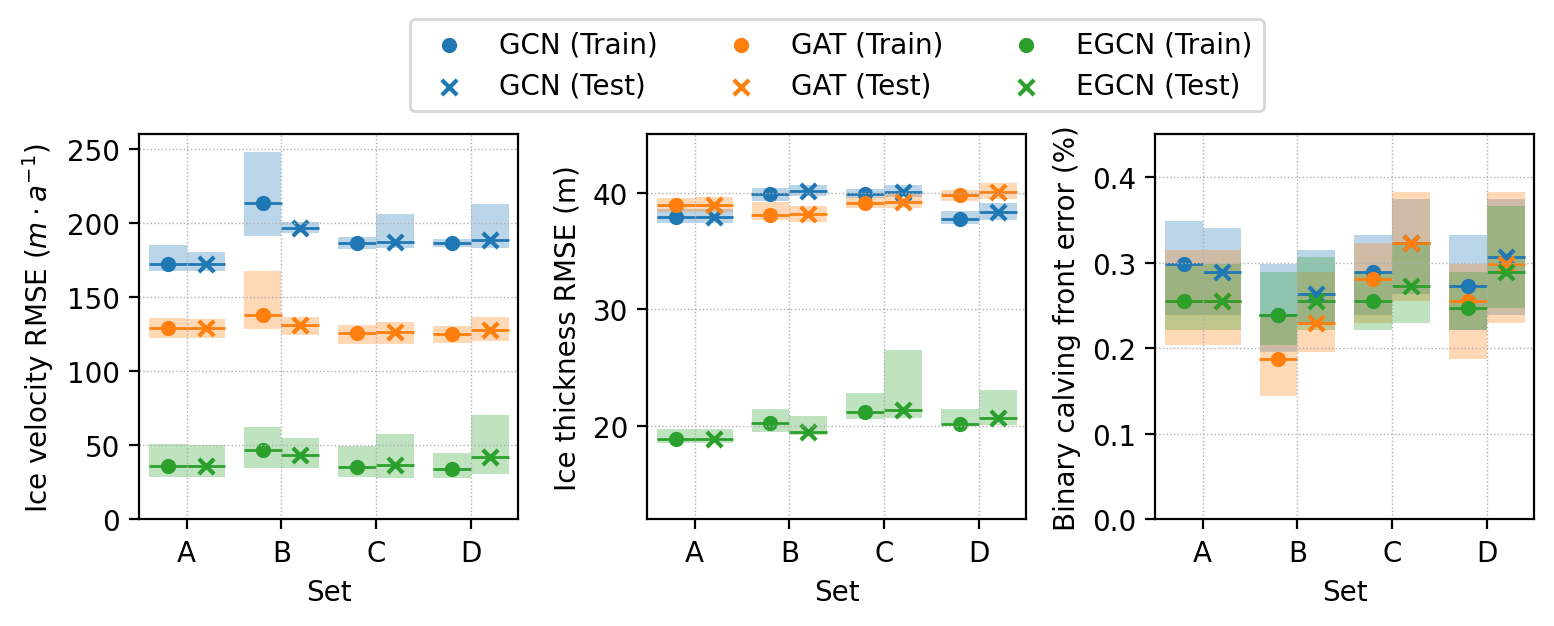

In [19]:
fig, ax = plt.subplots(1,3, figsize = (9,2.5), dpi = 200)
plt.subplots_adjust(wspace=0.34)

colors = ["tab:blue", "tab:orange", "tab:green"]
offset = 0.2

for i, model_type in enumerate(["GCN", "GAT", "EGCN"]):
    ax[0].scatter(train_avgv.index-offset, train_avgv[model_type], color = colors[i], s = 180, lw = 1, marker = "_")
    ax[0].scatter(test_avgv.index+offset, test_avgv[model_type], color = colors[i], s= 180, lw = 1, marker = "_")

    ax[1].scatter(train_avgh.index-offset, train_avgh[model_type], color = colors[i], s= 180, lw = 1, marker = "_")
    ax[1].scatter(test_avgh.index+offset, test_avgh[model_type], color = colors[i], s= 180, lw = 1, marker = "_")

    ax[2].scatter(train_avgm.index-offset, train_avgm[model_type], color = colors[i], s = 180, lw = 1, marker = "_")
    ax[2].scatter(test_avgm.index+offset, test_avgm[model_type], color = colors[i], s= 180, lw = 1, marker = "_")

    ax[0].scatter(train_avgv.index-offset, train_avgv[model_type], color = colors[i], s = 20, marker = "o")
    ax[0].scatter(test_avgv.index+offset, test_avgv[model_type], color = colors[i], s= 30, marker = "x")

    ax[1].scatter(train_avgh.index-offset, train_avgh[model_type], color = colors[i], s= 20, marker = "o", label = f"{model_type} (Train)")
    ax[1].scatter(test_avgh.index+offset, test_avgh[model_type], color = colors[i], s= 30,  marker = "x", label = f"{model_type} (Test)")

    ax[2].scatter(train_avgm.index-offset, train_avgm[model_type], color = colors[i], s = 20, marker = "o")
    ax[2].scatter(test_avgm.index+offset, test_avgm[model_type], color = colors[i], s= 30, marker = "x")

    for k in train_avgv.index:
        # ax[0].axhline(train_avgv[model_type][k], k-offset*1, k, color = colors[i], lw = 2)
        # ax[0].axhline(test_avgv[model_type][k], k, k+offset*1, color = colors[i], lw = 2)
        # print(k-offset, k)
        ax[0].fill_between([k-2*offset, k], train_avgv[model_type + "_q25"][k], train_avgv[model_type + "_q75"][k],
                           lw = 0, alpha=0.3, color=colors[i], zorder = 0)
        ax[0].fill_between([k, k+2*offset], test_avgv[model_type + "_q25"][k], test_avgv[model_type + "_q75"][k],
                           lw = 0, alpha=0.3, color=colors[i], zorder = 0)

        ax[1].fill_between([k-2*offset, k], train_avgh[model_type + "_q25"][k], train_avgh[model_type + "_q75"][k],
                           lw = 0, alpha=0.3, color=colors[i], zorder = 0)
        ax[1].fill_between([k, k+2*offset], test_avgh[model_type + "_q25"][k], test_avgh[model_type + "_q75"][k],
                           lw = 0, alpha=0.3, color=colors[i], zorder = 0)

        ax[2].fill_between([k-2*offset, k], train_avgm[model_type + "_q25"][k], train_avgm[model_type + "_q75"][k],
                           lw = 0, alpha=0.3, color=colors[i], zorder = 0)
        ax[2].fill_between([k, k+2*offset], test_avgm[model_type + "_q25"][k], test_avgm[model_type + "_q75"][k],
                           lw = 0, alpha=0.3, color=colors[i], zorder = 0)

ax[1].legend(loc = "center", bbox_to_anchor = [0.5, 1.18], ncol = 3)

ax[0].set_ylim(0, 260)
ax[1].set_ylim(12, 45)
ax[2].set_ylim(0, 0.45)

ax[0].set_ylabel("Ice velocity RMSE ($m \cdot a^{-1}$)")
ax[1].set_ylabel("Ice thickness RMSE (m)")
ax[2].set_ylabel("Binary calving front error (%)")

for a in ax:
    a.set_xticks([0, 1, 2, 3], ["A", "B", "C", "D"])
    a.grid(lw = 0.5, ls = ":")
    a.set_xlabel("Set")
    a.set_xlim(-0.5, 3.5)
    # a.legend()

## Draw result maps

In [3]:
from rasterio.plot import show
import rasterio

def draw_tri_map(triang, triang2, y_true, y_pred, c, idxs, years_real, model_type, label):
    vmax = [8000, 8000, 1400, 1, 8000]
    vmin = [-8000, -8000, 0, -1, 0]
    cmap = ["RdBu_r", "RdBu_r", "viridis", "viridis", "jet"]
    
    xext = [280*1000, 320*1000]
    yext = [-2590*1000, -2550*1000]

    fig, ax = plt.subplots(2, len(idxs), figsize = (len(idxs)*2,2*2), dpi=200, sharey=True, sharex=True,
                           subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude = 70)})
    plt.subplots_adjust(hspace=0.05, wspace=0.05)

    # Visible image as a background
    src = rasterio.open('D:\\ISSM\\Helheim\\snapshot-2023-06-20T00_00_00Z.tif')

    for k, idx in enumerate(idxs):

        ice_true = y_true[idx, :, 3]
        th_true = y_true[idx, :, 2]
        ice_pred = y_pred[idx, :, 3]
        th_pred = y_pred[idx, :, 2]

        triang.set_mask((th_true[triang.triangles].mean(axis=1) <= 20) | (ice_true[triang.triangles].mean(axis=1) > 0)) # 
        triang2.set_mask((th_pred[triang2.triangles].mean(axis=1) <= 30) | (ice_pred[triang2.triangles].mean(axis=1) > 0)) # 

        val_true = y_true[idx, :, c]
        val_pred = y_pred[idx, :, c]
        val_diff = val_pred - val_true

        true_map = ax[0, k].tripcolor(triang, val_true, vmin = vmin[c], vmax = vmax[c], cmap = cmap[c])
        # pred_map = ax[1, k].tripcolor(triang2, val_pred, vmin = vmin[c], vmax = vmax[c], cmap = cmap[c])
        diff_map = ax[1, k].tripcolor(triang2, val_diff, vmin = -vmax[c]/15, vmax = vmax[c]/15, cmap = "RdBu")

        ax[0, k].annotate(f"ISSM", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=10, ha='right', va='top')
        # ax[1, k].annotate(f"{model_type.upper()}", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=10, ha='right', va='top')
        ax[1, k].annotate(f"{model_type.upper()}-ISSM", xy=(0.97, 0.97), xycoords='axes fraction', fontsize=10, ha='right', va='top')
        
        for i in range(0, ax.shape[0]):
            xlims = ax[i, k].set_xlim(xext[0], xext[1])
            ylims = ax[i, k].set_ylim(yext[0], yext[1])

            show(src.read(), transform=src.transform, ax = ax[i, k])
            
            ax[i, k].gridlines(crs=ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude = 70), draw_labels=False, linewidth=0.5, \
                                color='gray', alpha=0.5, linestyle='--', zorder=10)
            # ax[i].grid(ls = ":", lw = 0.5)
            ax[i, k].set_ylabel("km")
            ax[i, k].set_xlabel("km")
            jday = int(years_real [idx%len(years_real)]%1 * 365 + 1)
            year = int(years_real [idx%len(years_real)]//1)
            time_str = datetime.strftime(datetime.strptime(f'{year}{jday:03d}', '%Y%j'), '%Y')

        ax[0, k].set_title(f"{time_str}", fontsize = 10)
        
    src.close()
    
    plt.savefig(f"D:\\ISSM\\Helheim\\Figures\\Maps_{label}.png", bbox_inches = "tight")
    plt.close()

In [ ]:
# Convert ISSM unstructured meshes into triangular meshes
triang = tri.Triangulation(xc[:, 0], yc[:, 0], elements)
triang2 = tri.Triangulation(xc[:, 0], yc[:, 0], elements)

# triang2.set_mask((ls2[triang2.triangles].mean(axis=1) > 0)) # 
ls2 = get_levelset(xc, yc, H, vxp, vyp, triang, sigma, rate, ls, mr)
ls2 = y_pred_all[20, :, 3]

a0 = plt.tricontour(xc[:,0], yc[:,0], ls2, levels = [0], zorder = 10)
paths = a0.collections[0].get_paths()[0].vertices #.properties()['paths'][0]
xf0 = paths[:, 0] # trix(paths[:, 0], paths[:,1]).data
yf0 = paths[:, 1] # triy(paths[:, 0], paths[:,1]).data

plt.tripcolor(triang2, ls2, cmap = "RdBu", zorder = 0, vmax = 1000, vmin = -1000)
plt.xlim(280000, 315000)
plt.ylim(-2590000, -2540000)
plt.colorbar()

In [254]:
train_num = 1

if train_num == 1:
    train_list = ["075", "090", "105"]
elif train_num == 2:
    train_list = ["070", "075", "080"]
elif train_num == 3:
    train_list = ["085", "090", "095"]
elif train_num == 4:
    train_list = ["100", "105", "110"]
elif train_num == 5:
    train_list = ["070", "075", "080", "090", "095", "100", "105", "110"]

train_files, val_files, test_gnn_files = generate_list(region = "Helheim", folder = "D:\\ISSM\\Helheim\\data_v2",
                                                       model = "gnn", train = train_list)

initial = "flowt"
if initial == "flow":
    in_channels = 4; out_channels = 3;
elif initial == "flowt":
    in_channels = 7; out_channels = 4;
elif initial == "flowa":
    in_channels = 9; out_channels = 4;

hidden_channels = 128
post_combine = False

torch.cuda.empty_cache()

idxs = np.arange(30, 260, 110)

for i in [0, len(test_gnn_files)-1]:

    test_graph = GNN_Helheim_Dataset(test_gnn_files[i:i+1], initial)

    n_nodes = len(test_graph[0].nodes())
    timestep = len(test_graph)
    edge_feat_size = test_graph[0].edata['slope'].shape[1]

    test_loader = GraphDataLoader(test_graph, batch_size=1, shuffle=False)  #DataLoader(test_grid, batch_size=1, shuffle=False)
    r = test_gnn_files[i].split("_r")[1][:3]
    
    for model_type in ["egnn", "gat", "gcn"]:
    
        if model_type == "gcn":
            model = GCN(in_channels, out_channels, hidden_channels)  # Graph convolutional network    
        elif model_type == "mlp":
            model = MLP(in_channels, out_channels, hidden_channels)  # Fully connected network
        elif model_type == "gat":
            model = GAT(in_channels, out_channels, hidden_channels)  # Graph attention network 
        # elif model_type == "egcn":
        #     model = EGCN(in_channels, out_channels-2, hidden_channels, edge_feat_size) # Equivariant Graph convolutional network
        elif model_type == "egnn":
            model = EGNN(in_channels, out_channels-2, hidden_channels, edge_feat_size) # Equivariant Graph convolutional network
    
        for device_name in ["cpu"]:
    
            print(f"Model: {model_type}, Device: {device_name}")
    
            emulator = f"D:\\ISSM\\Helheim\\model\\torch_dgl_Helheim{initial.upper()}_{model_type}_23466_train{train_num}_lr0.001_in{in_channels}_ch{out_channels}_ft{hidden_channels}_gpu8.pth"
            device = torch.device(device_name)
    
            if device_name == "cuda":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.to(device)
            elif device_name == "cpu":
                model = nn.DataParallel(model)
                model.load_state_dict(torch.load(emulator, map_location=device))
                model = model.module.to(device)
    
            model.eval()

            total_params = sum(p.numel() for p in model.parameters())
            print(f"MODEL: {model_type}; Number of parameters: {total_params}")

            y_true_all = np.zeros([timestep, n_nodes, 4])
            y_pred_all = np.zeros([timestep, n_nodes, 4])    
    
            t1 = 0      

            triang = tri.Triangulation(xc[:, 0], yc[:, 0], elements)
            triang2 = tri.Triangulation(xc[:, 0], yc[:, 0], elements)
            
            for j, bg in tqdm(enumerate(test_loader)):
    
                t0 = time.time()
    
                bg = bg.to(device)
                feats = bg.ndata['feat'][:, 2:]
                
                coord_feat = bg.ndata['feat'][:, :2]
            
                # Spatial & ice thickness filtering for model training
                idx = torch.where((coord_feat[:, 0]>15) & (coord_feat[:, 1] < 10))[0].to(device)
                
                edge_feat = bg.edata['weight'].float() #.repeat(1, 2)
                labels = bg.ndata['label'][:, :]
                    
                pred = model(bg, feats[:, :in_channels], post_combine).cpu().detach().numpy()
                    
                y_pred = np.zeros([feats.shape[0], 4]) # pred.cpu().detach().numpy() * scaling
                y_true = np.zeros([feats.shape[0], 4]) # labels.cpu().detach().numpy() * scaling   
            
                feats = feats.cpu().detach().numpy()
                labels = labels.cpu().detach().numpy()
            
                rate = (feats[0, -1]*100+50)*1e4
                smb = feats[:, -3]
                mr = feats[:, -2] * 3000
            
                y_true[:, 0] = labels[:, 0] * 10000
                y_true[:, 1] = labels[:, 1] * 10000
                y_true[:, 2] = labels[:, 3] * 5000
            
                if initial == "flow":
                    H = feats[:, 0] * 5000
                    vxp = pred[:, 0] * 10000
                    vyp = pred[:, 1] * 10000
                    sigma = pred[:, 2] * (1e4*1e6)
                    ls = feats[:, 3]
                    H2 = get_massbalance(xc, yc, H, vxp, vyp, triang, smb)
                    ls2 = get_levelset(xc, yc, H, vxp, vyp, triang, sigma, rate, ls, mr)
                    y_true[:, 3] = labels[:, 4] * 1000000
                elif initial == "flowt":                    
                    H = feats[:, 0] * 5000
                    vxp = pred[:, 0] * 10000
                    vyp = pred[:, 1] * 10000
                    sigma = pred[:, 2] * (1e4*1e6)
                    ls = feats[:, 3] * 1000000
                    H2 = pred[:, 3] * 5000
                    ls2 = get_levelset_num(xc, yc, H, vxp, vyp, triang, sigma, rate, ls, mr)
                    y_true[:, 3] = labels[:, 4] * 1000000
                    feats2 = feats.copy()
                    feats2[:, 0] = H2 / 5000
                    feats2[:, 3] = ls2 / 1000000
                    feats2[:, 4] = vxp / 10000
                    feats2[:, 5] = vyp / 10000
                elif initial == "flowa":
                    H = feats[:, 0] * 5000
                    vxp = pred[:, 0] * 10000
                    vyp = pred[:, 1] * 10000
                    # sigma = pred[:, 2] * (1e4*1e6)
                    # ls = feats[:, 3]
                    H2 = pred[:, 3] * 5000
                    ls2 = pred[:, 2] * 1000000
                    y_true[:, 3] = labels[:, 2]
                    feats2 = feats.copy()
                    feats2[:, 0] = H2 / 5000
                    feats2[:, 3] = ls2 / 1000000
                    feats2[:, 4] = vxp / 10000
                    feats2[:, 5] = vyp / 10000
            
                y_pred[:, 0] = vxp #[small]
                y_pred[:, 1] = vyp #[small]
                y_pred[:, 2] = H2 #[small]
                y_pred[:, 3] = ls2 #[small]
    
                t1 += time.time() - t0
            
                mask_true = convert_binary(y_true[:, -1], feats[:, -2])
                mask_pred = convert_binary(y_pred[:, -1], feats[:, -2])
            
                y_true_all[j,:,:4] = y_true
                y_pred_all[j,:,:4] = y_pred

            y_true_all = add_vel(y_true_all)
            y_pred_all = add_vel(y_pred_all)          
            
            for c in [2, 4]:  
                label = f"triang_{initial}_{model_type.upper()}_sigma{r}_ch{c}" #Maps_GCN_sigma0.95_ch2
                draw_tri_map(triang, triang2, y_true_all, y_pred_all, c, idxs, years_real, model_type, label)
                        
print("DONE!")

100%|████████████████████████████████████████████████████████████████████████████| 1/1 [00:30<00:00, 30.01s/it]


Model: egnn, Device: cpu
MODEL: egnn; Number of parameters: 104066


260it [01:03,  4.13it/s]


Model: gat, Device: cpu
MODEL: gat; Number of parameters: 205572


260it [01:57,  2.20it/s]


...

Model: gat, Device: cpu
MODEL: gat; Number of parameters: 205572


260it [01:59,  2.18it/s]


Model: gcn, Device: cpu
MODEL: gcn; Number of parameters: 67588


260it [00:45,  5.77it/s]


DONE!
